In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail/validation.csv
/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail/train.csv
/kaggle/input/datasets/gowrishankarp/newspaper-text-summarization-cnn-dailymail/cnn_dailymail/test.csv


In [4]:
!pip install transformers datasets evaluate rouge_score --quiet

In [5]:
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", "3.0.0")

dataset

README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})

In [6]:
sample = dataset["train"][0]

print("ARTICLE:\n")
print(sample["article"])

print("\n" + "="*80 + "\n")

print("SUMMARY:\n")
print(sample["highlights"])

ARTICLE:

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Deta

In [9]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "facebook/bart-large-cnn"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

In [10]:
article = dataset["test"][0]["article"]

inputs = tokenizer(
    article,
    return_tensors="pt",
    truncation=True,
    max_length=1024
).to(device)

summary_ids = model.generate(
    inputs["input_ids"],
    max_length=150,
    min_length=40,
    num_beams=4,
    early_stopping=True
)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("ARTICLE:\n")
print(article[:1000])

print("\n" + "="*80 + "\n")

print("GENERATED SUMMARY:\n")
print(summary)

ARTICLE:

(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination into the situation in Palestinian territories, paving the way for possible war crimes investigations against Israelis. As members of the court, Palestinians may be subject to counter-charges as well. Israel and the United States, neither of which is an ICC member, opposed the Palestinians' efforts to join the body. But Palestinian Foreign Minister Riad al-Malki, speaking at Wednesday's ce

In [11]:
import evaluate

rouge = evaluate.load("rouge")

reference_summary = dataset["test"][0]["highlights"]

results = rouge.compute(
    predictions=[summary],
    references=[reference_summary]
)

print("REFERENCE SUMMARY:\n")
print(reference_summary)

print("\n" + "="*80 + "\n")

print("ROUGE SCORES:\n")
print(results)

REFERENCE SUMMARY:

Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .


ROUGE SCORES:

{'rouge1': np.float64(0.5352112676056339), 'rouge2': np.float64(0.37681159420289856), 'rougeL': np.float64(0.47887323943661975), 'rougeLsum': np.float64(0.47887323943661975)}


In [12]:
import numpy as np

predictions = []
references = []

for i in range(10):   # evaluate 10 articles
    article = dataset["test"][i]["article"]
    ref_summary = dataset["test"][i]["highlights"]

    inputs = tokenizer(
        article,
        return_tensors="pt",
        truncation=True,
        max_length=1024
    ).to(device)

    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=150,
        min_length=40,
        num_beams=4,
        early_stopping=True
    )

    pred_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    predictions.append(pred_summary)
    references.append(ref_summary)

results = rouge.compute(
    predictions=predictions,
    references=references
)

print("Average ROUGE Scores:\n")
print(results)

Average ROUGE Scores:

{'rouge1': np.float64(0.3652034046423771), 'rouge2': np.float64(0.15808585243246367), 'rougeL': np.float64(0.278041031104737), 'rougeLsum': np.float64(0.30247429613046883)}


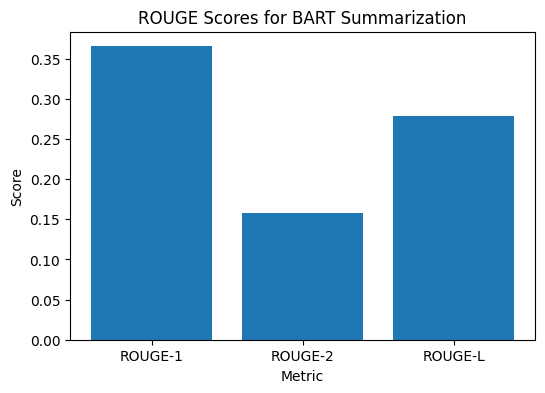

In [13]:
import matplotlib.pyplot as plt

scores = [
    results["rouge1"],
    results["rouge2"],
    results["rougeL"]
]

labels = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)

plt.title("ROUGE Scores for BART Summarization")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.show()

In [14]:
import pandas as pd

# إعداد البيانات
df = pd.DataFrame({
    "article": [dataset["test"][i]["article"] for i in range(len(predictions))],
    "generated_summary": predictions,
    "reference_summary": references
})

# حفظها كـ CSV
df.to_csv("cnn_dailymail_summaries.csv", index=False)

print("Saved summaries to 'cnn_dailymail_summaries.csv' ✅")

Saved summaries to 'cnn_dailymail_summaries.csv' ✅


In [17]:
!pip install sumy --quiet

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 73.2 MB/s eta 0:00:00:00:010:01


In [18]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer

article = dataset["test"][0]["article"]

parser = PlaintextParser.from_string(article, Tokenizer("english"))
summarizer = TextRankSummarizer()

summary = summarizer(parser.document, sentences_count=5)
summary_text = " ".join(str(sentence) for sentence in summary)

print("Extractive Summary:\n", summary_text)

Extractive Summary:
 (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. "As Palestine formally becomes a State Party to the Rome Statute today, the world is also a step closer to ending a long era of impunity and injustice," he said, according to an ICC news release. Judge Kuniko Ozaki, a vice president of the ICC, said acceding to the treaty was just the first step for the Palestinians. "As the Rome Statute today enters into force for the State of Palestine, Palestine acquires all the rights as well as responsibilities that come with being a State Party to the Statute. But the ICC begs to differ with the definition of a state for its purposes and refers to the territories as "Palestine."


NameError: name 'results_abstractive' is not defined